# Nature Paper Plots Generator

This notebook generates plots from sensitivity analysis data for the nature paper.
Plots generated:
1. Scenario plots (NZE, APS, STEPS) showing emissions relative to 2022 baseline
2. Stated targets comparison
3. Uncertainty ranges


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


## Setup and Data Loading


In [47]:
# Define paths
BU_RESULTS_DIR = Path("./BU_results")
PLOTS_DATA_DIR = BU_RESULTS_DIR / "plots_data"
NATURE_PLOTS_DIR = Path("./nature_plots")

# Create output directory
NATURE_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {NATURE_PLOTS_DIR.absolute()}")
print(f"Plots data directory: {PLOTS_DATA_DIR.absolute()}")

# Scenario values
start_year = 2022
end_year = 2030
emissions22 = 2623
nze30 = 2118
aps30 = 2474
steps30 = 2685

r_nze = (nze30 / emissions22) ** (1 / (end_year - start_year)) - 1
r_aps = (aps30 / emissions22) ** (1 / (end_year - start_year)) - 1
r_steps = (steps30 / emissions22) ** (1 / (end_year - start_year)) - 1

Output directory: c:\Users\hamada.saleh\Documents\Python Scripts\bottom_up_alignment\nature_plots
Plots data directory: c:\Users\hamada.saleh\Documents\Python Scripts\bottom_up_alignment\BU_results\plots_data


In [68]:

# Load the sensitivity analysis data for each scenario
print("\nLoading sensitivity data...")

nze_data = pd.read_excel(PLOTS_DATA_DIR / "nze_elec_intensity_sensitivity_all_data.xlsx")
aps_data = pd.read_excel(PLOTS_DATA_DIR / "aps_elec_intensity_sensitivity_data.xlsx")
steps_data = pd.read_excel(PLOTS_DATA_DIR / "steps_elec_intensity_sensitivity_data.xlsx")

histo = nze_data.loc[nze_data['period'] == 'historical']
histo_22 = histo.loc[histo['year'] == 2022, 'Emissions (Gt)'].iloc[0]
histo["Emissions (Gt)_normalized"] = histo["Emissions (Gt)"] / histo_22

print(f"NZE data shape: {nze_data.shape}")
print(f"APS data shape: {aps_data.shape}")
print(f"STEPS data shape: {steps_data.shape}")

# Load stated targets data
stated_data = pd.read_csv(PLOTS_DATA_DIR / "stated_single_stated_traj_scenarios_EAF_decarb.csv")
print(f"Stated data shape: {stated_data.shape}")

# Load uncertainty projections
uncertainty_data = pd.read_excel(BU_RESULTS_DIR / "UR_uncertainty" / "ur_uncertainty_projections.xlsx")
print(f"Uncertainty data shape: {uncertainty_data.shape}")

print("\nData loaded successfully!")



Loading sensitivity data...
NZE data shape: (67, 10)
APS data shape: (67, 10)
STEPS data shape: (67, 10)
Stated data shape: (54, 7)
Uncertainty data shape: (9, 9)

Data loaded successfully!


## Plot 1: Scenario Plots Relative to 2022 Baseline

Create one plot for each scenario (NZE, APS, STEPS) showing emissions relative to 2022


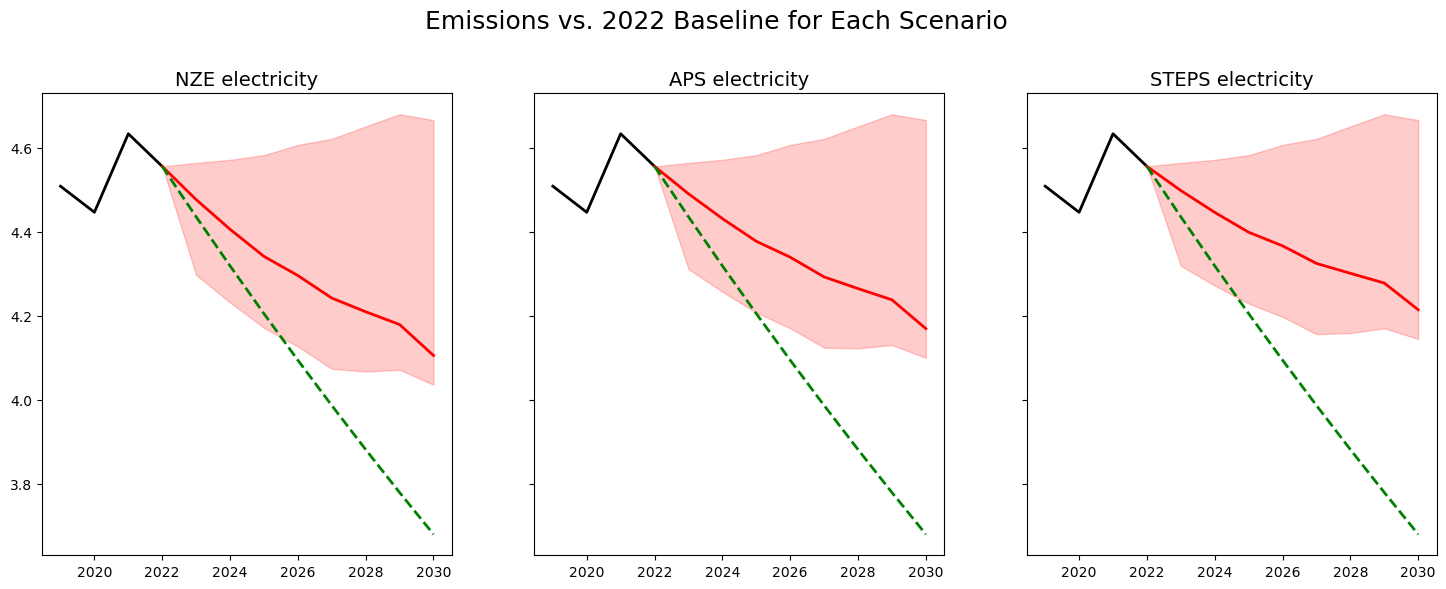

In [ ]:
methods = ["country_techno UR", "constant market share"]
scenarios = ["NZE", "APS", "STEPS"]

scn_prod = "NZE"
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)
for (scn_elec, ax) in zip(scenarios, axs):
    proj = nze_data.loc[(nze_data['period'] == 'projected') & (nze_data['trajectory_type'] == f"{scn_prod} with {scn_elec} elec intensity ({methods[1]})")]
    # Add a row to proj for year 2022 with values from histo_22 for the high and low
    # The histo_22 is a scalar, but for consistency add a new row at the start
    new_row = {
        'year': 2022,
        'Emissions (Gt)': histo_22,
        'Emissions_low (Gt)': histo_22,
        'Emissions_high (Gt)': histo_22
    }
    proj.loc[(proj['year'] == 2022), ["Emissions_low (Gt)", "Emissions_high (Gt)"]] = histo_22
    scn_traj = pd.DataFrame({'year': np.arange(2022, end_year+1), 'Emissions (Gt)': histo_22})
    scn_traj['Emissions (Gt)'] = scn_traj['Emissions (Gt)'] * (1 + r_nze) ** (scn_traj['year'] - 2022)

    ax.plot(histo['year'], histo['Emissions (Gt)'], 'k-', linewidth=2)
    ax.plot(proj['year'], proj['Emissions (Gt)'], 'r-', linewidth=2)
    ax.plot(scn_traj['year'], scn_traj['Emissions (Gt)'], linestyle='--', color='green', linewidth=2)

    # Add uncertainty in fill between
    # If uncertainty columns exist (e.g., 'Emissions_low (Gt)' and 'Emissions_high (Gt)'), shade the region between them
    if 'Emissions_low (Gt)' in proj.columns and 'Emissions_high (Gt)' in proj.columns:
        ax.fill_between(
            proj['year'],
            proj['Emissions_low (Gt)'],
            proj['Emissions_high (Gt)'],
            color='red',
            alpha=0.2,
            label='uncertainty'
        )

    ax.set_title(f"{scn_elec} electricity", fontsize=14)

fig.suptitle("Emissions vs. 2022 Baseline for Each Scenario", fontsize=18, y=1.02)
fig.savefig(f"nature_plots/{scn_prod}_elec_intensity_sensitivity.png", bbox_inches="tight", dpi=200)

In [37]:
proj

,year,period,elec_scenario,method,trajectory_type,Emissions (Gt),Emissions_low (Gt),Emissions_high (Gt),production,Emission Factor (tCO2/t)
49,2022,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.556722,NaN,NaN,1.875301e+09,2.429862
50,2023,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.499160,4.319573,4.565084,1.896727e+09,2.372065
51,2024,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.447052,4.272644,4.572330,1.907676e+09,2.331136
52,2025,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.399685,4.229552,4.583544,1.918620e+09,2.293151
53,2026,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.367263,4.197850,4.607936,1.929567e+09,2.263339
54,2027,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.325352,4.156616,4.622309,1.940514e+09,2.228972
55,2028,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.301719,4.159159,4.651976,1.951461e+09,2.204358
56,2029,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.278615,4.170670,4.681017,1.962410e+09,2.180286
57,2030,projected,STEPS,company_UR,NZE with STEPS elec intensity (constant market...,4.214862,4.145172,4.667221,1.973357e+09,2.135885


## Plot 2: Stated Targets


In [96]:
stated_histo_path = PLOTS_DATA_DIR / "historical_emissions_stated_targets.xlsx"
stated_proj_path = PLOTS_DATA_DIR / "stated_single_stated_traj_scenarios_EAF_decarb.csv"
stated_histo = pd.read_excel(stated_histo_path)
stated_data = pd.read_csv(stated_proj_path)
stated22 = stated_data.loc[(stated_data["Source"] == "Projected BU emissions (constant market share)") & (stated_data["Scenario"] == "NZE"), "Emissions"].iloc[0]
stated_data[[f"{col}_normalized" for col in ["Emissions", "Emissions_low", "Emissions_high"]]] = stated_data[["Emissions", "Emissions_low", "Emissions_high"]] / stated22
stated_histo["Emissions_normalized"] = stated_histo["BU emissions"] / stated22

In [97]:
display(stated_histo.columns)
display(stated_data.columns)

Index(['year', 'BU emissions', 'Attributed production',
       'Attributed capacity (ttpa)', 'Number_of_companies', 'Emissions (Gt)',
       'Production (Mt)', 'Capacity (Mt)', 'Emissions_normalized'],
      dtype='object')

Index(['Unnamed: 0', 'year', 'Source', 'Emissions', 'Scenario',
       'Emissions_low', 'Emissions_high', 'Emissions_normalized',
       'Emissions_low_normalized', 'Emissions_high_normalized'],
      dtype='object')

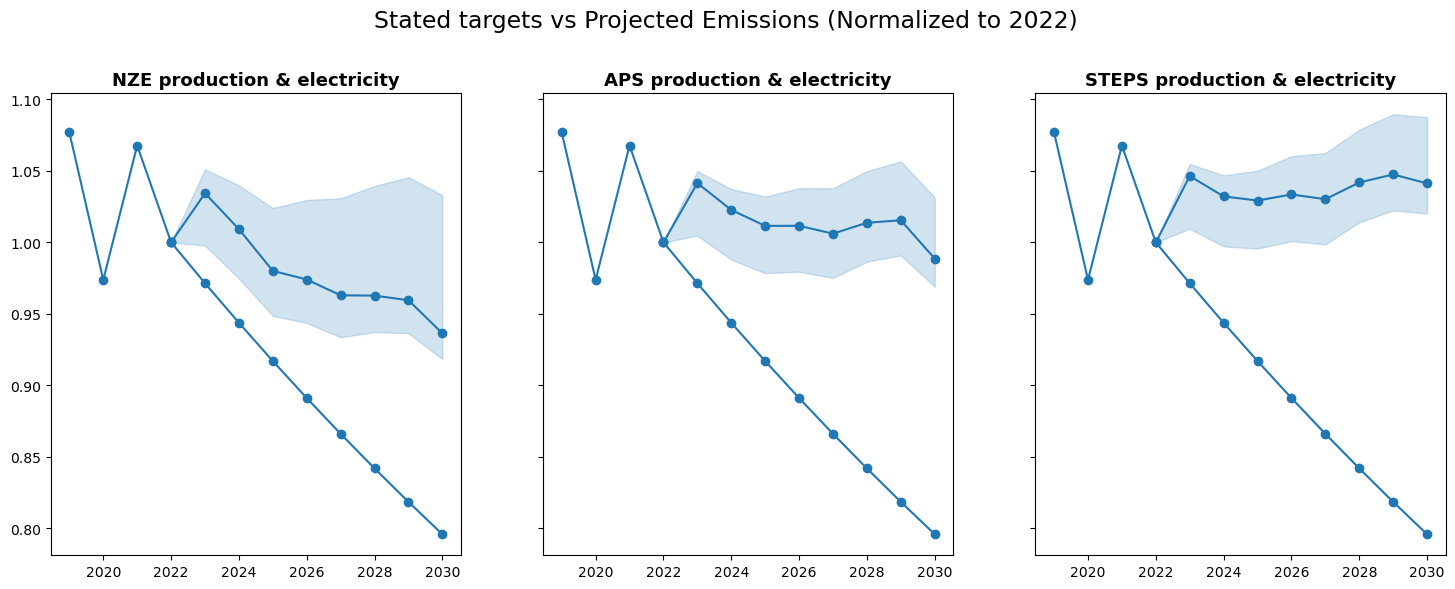

In [100]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)
for scn_prod_elec, ax in zip(["NZE", "APS", "STEPS"], axs):
    # histo
    ax.plot(stated_histo["year"], stated_histo["Emissions_normalized"], marker='o', label="Stated", color="tab:blue")
    # proj
    stated_traj = stated_data.loc[(stated_data["Source"] == "Stated emissions") & (stated_data["Scenario"] == scn_prod_elec)]
    proj_traj = stated_data.loc[(stated_data["Source"] == "Projected BU emissions (constant market share)") & (stated_data["Scenario"] == scn_prod_elec)]
    ax.plot(proj_traj["year"], proj_traj["Emissions_normalized"], marker='o', label="Stated", color="tab:blue")
    ax.plot(stated_traj["year"], stated_traj["Emissions_normalized"], marker='o', label="Stated", color="tab:blue")
    if "Emissions_low_normalized" in proj_traj.columns and "Emissions_high_normalized" in proj_traj.columns:
        ax.fill_between(
            proj_traj["year"],
            proj_traj["Emissions_low_normalized"],
            proj_traj["Emissions_high_normalized"],
            color="tab:blue",
            alpha=0.2,
            label="uncertainty"
        )
    ax.set_title(f"{scn_prod_elec} production & electricity", fontsize=13, fontweight='bold')
# Add suptitle to the figure after the loop ends
fig.suptitle("Stated targets vs Projected Emissions (Normalized to 2022)", fontsize=17, y=1.02)
fig.show()


## Plot 3: Uncertainty Ranges

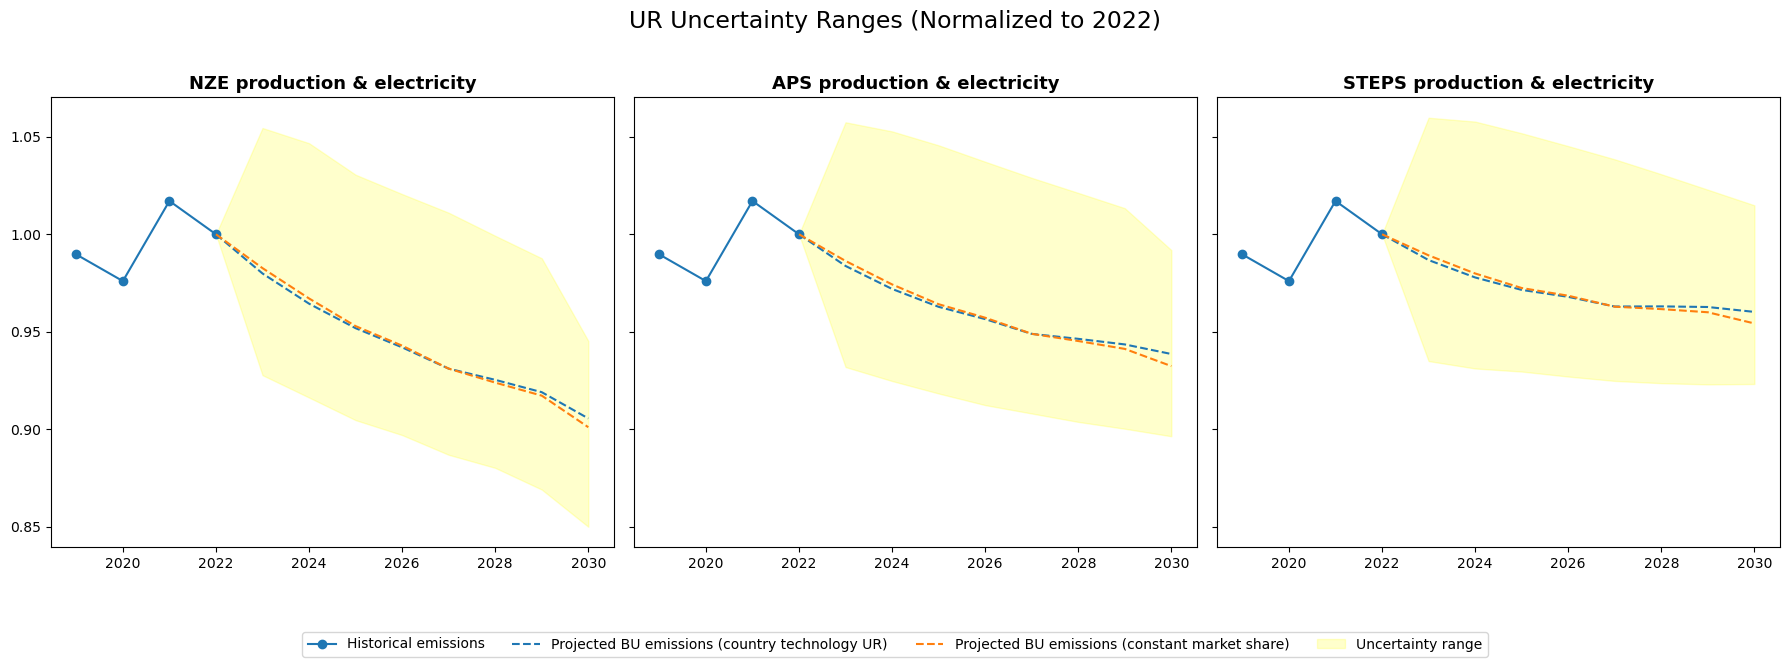

In [110]:
ur_uncertainty_path = BU_RESULTS_DIR / "UR_uncertainty" / "ur_uncertainty_projections.xlsx"
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# We'll collect handles and labels only from the first subplot
handles_labels = None

for i, (scn_prod_elec, ax) in enumerate(zip(["NZE", "APS", "STEPS"], axs)):
    ur_unct = pd.read_excel(ur_uncertainty_path, sheet_name=scn_prod_elec)
    curve1 = ax.plot(
        histo["year"], 
        histo["Emissions (Gt)_normalized"], 
        marker='o', 
        label="Historical emissions", 
        color="tab:blue"
    )
    curve2 = ax.plot(
        ur_unct["year"],
        ur_unct["constant_UR_normalized"],
        label="Projected BU emissions (country technology UR)",
        color="tab:blue",
        linestyle="--"
    )
    curve3 = ax.plot(
        ur_unct["year"],
        ur_unct["company_UR_normalized"],
        label="Projected BU emissions (constant market share)",
        color="tab:orange",
        linestyle="--"
    )
    fill = ax.fill_between(
        ur_unct["year"],
        ur_unct["carbon_efficiency_normalized"],
        ur_unct["carbon_intensity_normalized"],
        color="yellow",
        alpha=0.2,
        label="Uncertainty range"
    )
    ax.set_title(f"{scn_prod_elec} production & electricity", fontsize=13, fontweight='bold')

    if i == 0:
        # Only collect legend handles and labels from the first axis
        handles = []
        labels = []

        # Use labels from the actual artists
        for artist in [curve1[0], curve2[0], curve3[0], fill]:
            handles.append(artist)
            labels.append(artist.get_label())
        handles_labels = (handles, labels)

# Single legend below all subplots, all entries in a single row
if handles_labels is not None:
    fig.legend(
        handles_labels[0], handles_labels[1],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.07),
        ncol=len(handles_labels[0]),  # Force all legend items to one row
        frameon=True
    )
# Add suptitle after all subplots are created (outside loop in the cell)
fig.suptitle("UR Uncertainty Ranges (Normalized to 2022)", fontsize=17, y=1.02)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.show()

## Summary

All plots have been generated and saved to the `nature_plots` folder:
- `nze_elec_intensity_sensitivity.png` - NZE scenario electricity intensity sensitivity
- `aps_elec_intensity_sensitivity.png` - APS scenario electricity intensity sensitivity
- `steps_elec_intensity_sensitivity.png` - STEPS scenario electricity intensity sensitivity
- `stated_targets_comparison.pdf` - Stated targets vs projected emissions
- `uncertainty_ranges.pdf` - Global emissions with uncertainty bounds
